# Indian male: three close framings at mouth-strength 0.5

## tl;dr

The 0.5 audio-conditioning intervention successfully moderates large mouth openings at all three close framings. **The 1.25× pose is the best combined setting in this test:** it preserves its unmodified trajectory most strongly (**0.928 correlation**) while reducing p95 mouth opening by **24.6%** and retaining useful articulation. The 1.50× pose remains visually clear but is attenuated more heavily (mean −20.9%, p95 −32.1%) and retains the earlier head-cropping tradeoff.


## Context & Methods

All three clips were regenerated under one compiled graph with 30 process-local audio cross-attention hooks fixed at strength 0.5. Framings are 1.00×, 1.25×, and 1.50×; audio, seed 50, 320×576 output, four steps, and all other model settings are fixed. Each raw output hash differs from its unmodified counterpart.

**GPU provenance:** NVIDIA GeForce RTX 4070 SUPER, 12,282 MiB visible VRAM; driver 595.84; Torch 2.7.1+cu128 / CUDA 12.8; run date 2026-09-16. Pre-load GPU allocation was 2,487 MiB and was not stopped. Exact evidence is saved in `evidence-indian-male-closer-strength-0p5-20260916/results.json`.

### Key Assumptions

- The landmark opening proxy measures articulation magnitude, not phoneme accuracy.
- The process-local hook is an experimental intervention, not a production control or trained disentangled expression parameter.
- Visual conclusions come from five matched samples and full comparison playback, not a blinded human study.


## Data

Three new 250-frame clips at strength 0.5 are compared across pose and against the corresponding prior unmodified strength-1 clips.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

evidence = Path('evidence-indian-male-closer-strength-0p5-20260916')
run = json.loads((evidence / 'results.json').read_text())
motion = json.loads((evidence / 'mouth-motion.json').read_text())
rows = pd.DataFrame([{k: v for k, v in row.items() if k != 'opening_series'} for row in motion['rows']])
pose = pd.DataFrame([{k: v for k, v in row.items() if k != 'lag_scan_frames'} for row in motion['pose_comparisons']])
strength = pd.DataFrame([{k: v for k, v in row.items() if k != 'lag_scan_frames'} for row in motion['strength_comparisons']])
assert run['status'] == 'complete' and run['hook_count'] == 30 and len(run['rows']) == 3
assert all(row['differs_from_unmodified'] for row in run['rows'])
assert len(rows) == 3 and (rows['frames'] == 250).all() and (rows['detection_rate'] == 1).all()
rows

,label,strength,path,frames,detected,detection_rate,mean_face_width_px,mean_eye_span_px,mean_opening,p95_opening,opening_sd,mean_abs_frame_change
0,close-100,0.5,benchmarks/distance_lipsync/evidence-indian-ma...,250,250,1.0,133.278095,87.046501,0.093474,0.177876,0.047433,0.015504
1,closer-125,0.5,benchmarks/distance_lipsync/evidence-indian-ma...,250,250,1.0,167.043378,108.149412,0.091485,0.208043,0.061262,0.020346
2,closest-150,0.5,benchmarks/distance_lipsync/evidence-indian-ma...,250,250,1.0,199.425137,130.080345,0.073372,0.158519,0.045798,0.017971


## Results

In [2]:
order = ['close-100', 'closer-125', 'closest-150']
table = rows.set_index('label').reindex(order).join(strength.set_index('label')[
    ['zero_lag_correlation', 'mean_opening_change_pct', 'p95_opening_change_pct']])
table[['mean_face_width_px', 'mean_opening', 'p95_opening', 'mean_abs_frame_change',
       'zero_lag_correlation', 'mean_opening_change_pct', 'p95_opening_change_pct']].round(4)

,mean_face_width_px,mean_opening,p95_opening,mean_abs_frame_change,zero_lag_correlation,mean_opening_change_pct,p95_opening_change_pct
label,,,,,,,
close-100,133.2781,0.0935,0.1779,0.0155,0.8739,-11.2825,-25.1570
closer-125,167.0434,0.0915,0.2080,0.0203,0.9278,-9.3213,-24.5902
closest-150,199.4251,0.0734,0.1585,0.0180,0.8695,-20.8942,-32.0976


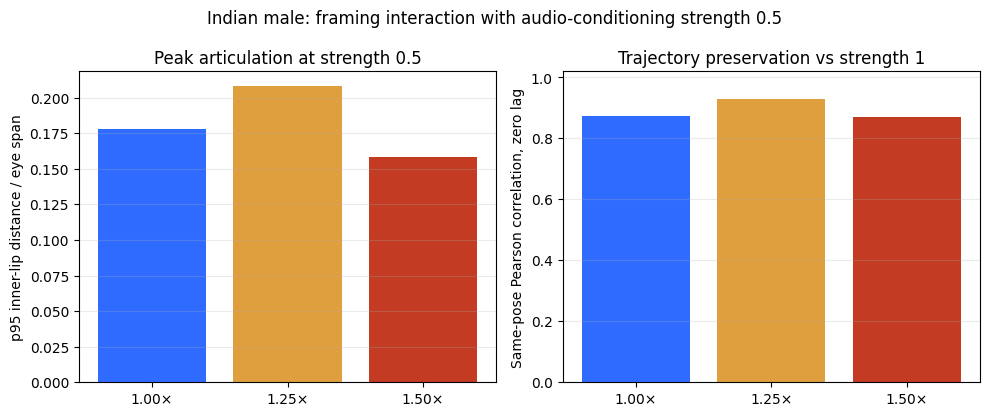

In [3]:
colors = ['#2F6BFF', '#E09F3E', '#C23B22']
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
axes[0].bar(['1.00×', '1.25×', '1.50×'], table['p95_opening'], color=colors)
axes[0].set_title('Peak articulation at strength 0.5')
axes[0].set_ylabel('p95 inner-lip distance / eye span')
axes[0].grid(axis='y', alpha=.25)

axes[1].bar(['1.00×', '1.25×', '1.50×'], table['zero_lag_correlation'], color=colors)
axes[1].set_ylim(0, 1.02)
axes[1].set_title('Trajectory preservation vs strength 1')
axes[1].set_ylabel('Same-pose Pearson correlation, zero lag')
axes[1].grid(axis='y', alpha=.25)
fig.suptitle('Indian male: framing interaction with audio-conditioning strength 0.5')
fig.tight_layout()
fig.savefig(evidence / 'pose-strength-0p5-effect.png', dpi=160, bbox_inches='tight')
plt.show()

Strength 0.5 reduces p95 opening by 25.2%, 24.6%, and 32.1% at 1.00×, 1.25×, and 1.50× respectively. The 1.25× pose retains the highest correlation with its own unmodified output and preserves visibly useful mouth movement. The 1.50× pose is both more tightly cropped and more attenuated.

## Takeaways

1. **1.25× + strength 0.5 is the best combined candidate from this run.** It balances visible mouth scale, moderated peaks, trajectory preservation, and composition headroom.
2. **1.50× remains the maximum-detail framing but is not automatically best with strength 0.5.** It receives the strongest attenuation and can crop the top of the head.
3. **1.00× remains coherent but offers fewer mouth pixels.** Its peak opening is reduced similarly to 1.25× without the visibility benefit.
4. Strength 0.5 is still experimental. It changes gaze/head/expression behavior as well as mouth opening and does not repair teeth detail.
5. A production default needs multiple utterances and seeds, plus phoneme-level or blinded perceptual validation.
